<a href="https://colab.research.google.com/github/vasubatra09/vasubatra09/blob/main/DecisionTrees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Income":[20,25,30,35,40,45,50,55],
    "Credit":[700,720,750,760,500,510,520,540],
    "Loan":["Yes","Yes","Yes","Yes","No","No","No","No"]
})

df

,Income,Credit,Loan
0,20,700,Yes
1,25,720,Yes
2,30,750,Yes
3,35,760,Yes
4,40,500,No
5,45,510,No
6,50,520,No
7,55,540,No


In [ ]:
print("Question:")
print("Which feature should become the root node?")

Question:
Which feature should become the root node?


In [ ]:
print("Let's try splitting using Income > 37.5")

Let's try splitting using Income > 37.5


In [ ]:
left = df[df["Income"] <= 37.5]
right = df[df["Income"] > 37.5]

print("LEFT NODE")
display(left)

print()

print("RIGHT NODE")
display(right)

LEFT NODE


,Income,Credit,Loan
0,20,700,Yes
1,25,720,Yes
2,30,750,Yes
3,35,760,Yes



RIGHT NODE


,Income,Credit,Loan
4,40,500,No
5,45,510,No
6,50,520,No
7,55,540,No


In [ ]:
print("Do we need another split?")

Do we need another split?


In [ ]:
df = pd.DataFrame({

"Income":[20,22,24,26,28,30],

"Credit":[700,680,550,720,500,480],

"Loan":["Yes","Yes","No","Yes","No","No"]

})

df

,Income,Credit,Loan
0,20,700,Yes
1,22,680,Yes
2,24,550,No
3,26,720,Yes
4,28,500,No
5,30,480,No


In [ ]:
left = df[df["Income"] <= 25]

right = df[df["Income"] > 25]

display(left)
display(right)

,Income,Credit,Loan
0,20,700,Yes
1,22,680,Yes
2,24,550,No


,Income,Credit,Loan
3,26,720,Yes
4,28,500,No
5,30,480,No


In [ ]:
second_split = right[right["Credit"] > 600]

display(second_split)

,Income,Credit,Loan
3,26,720,Yes


Real-World Dataset

In [ ]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
# Load the dataset

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

X.head()

Feature Matrix Shape : (569, 30)
Target Shape : (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
print(data.DESCR[:1500])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [ ]:
# Split into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [ ]:
# Build the Decision Tree

model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
# Predictions

predictions = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9474


In [ ]:
print(confusion_matrix(y_test, predictions))

[[38  5]
 [ 1 70]]


In [ ]:
print(classification_report(
    y_test,
    predictions,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.97      0.88      0.93        43
      benign       0.93      0.99      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



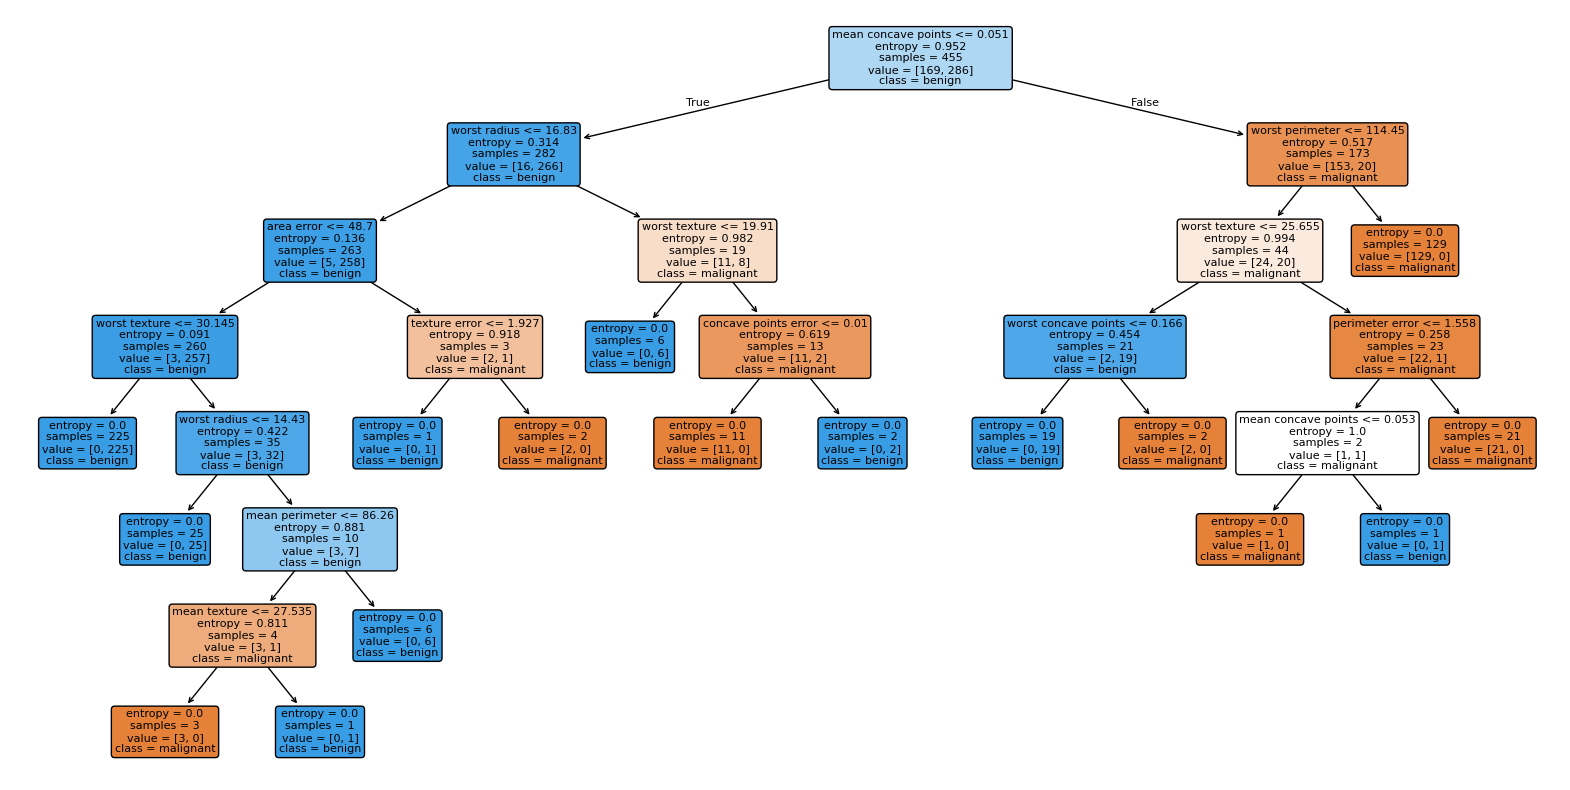

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [ ]:
for depth in [1,2,3,4,5,6,8,10]:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train,y_train)

    train_acc = model.score(X_train,y_train)

    test_acc = model.score(X_test,y_test)

    print(depth,train_acc,test_acc)

1 0.9208791208791208 0.8947368421052632
2 0.9296703296703297 0.9298245614035088
3 0.978021978021978 0.9473684210526315
4 0.9956043956043956 0.9473684210526315
5 0.9956043956043956 0.9473684210526315
6 0.9978021978021978 0.9385964912280702
8 1.0 0.9473684210526315
10 1.0 0.9473684210526315
